
# Task 2: Credit Risk Prediction

## Introduction
Financial institutions need reliable methods to evaluate loan applications. This project uses machine learning to predict loan approval status based on applicant information.

## Problem Statement
Build a classification model that predicts whether a loan application is likely to be approved.

## Dataset
Loan Prediction Dataset (Kaggle)

## Objectives
- Handle missing values
- Perform Exploratory Data Analysis (EDA)
- Visualize important features
- Train classification models
- Evaluate performance using Accuracy and Confusion Matrix


## Remove warnings

In [1]:
import warnings
warnings.filterwarnings('ignore')

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.style.use('default')


## Load Dataset

In [3]:

df = pd.read_csv('Loan_Data.csv')
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Dataset Overview

In [4]:

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
display(df.head())
display(df.describe())
df.info()


Shape: (614, 13)

Columns:
 ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


## Missing Values Analysis

In [5]:

df.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## Data Cleaning

In [6]:

if 'Loan_ID' in df.columns:
    df = df.drop('Loan_ID', axis=1)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(exclude='object').columns:
    df[col] = df[col].fillna(df[col].median())

print("Remaining Missing Values:", df.isnull().sum().sum())


Remaining Missing Values: 0


# Exploratory Data Analysis (EDA)

### Loan Status Distribution
**Observation:** Approved applications are usually higher than rejected applications.

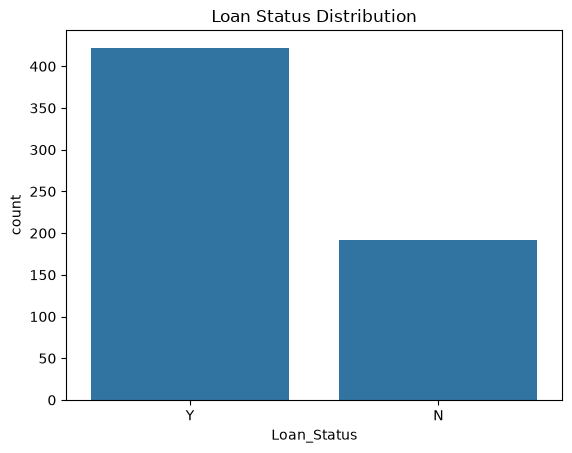

In [7]:
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.show()

### Gender vs Loan Status
**Observation:** Compare approval patterns across gender groups.

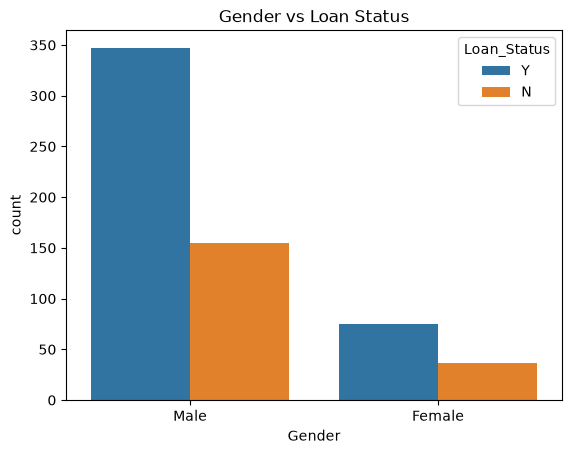

In [8]:
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title('Gender vs Loan Status')
plt.show()

### Education vs Loan Status
**Observation:** Education level may influence approval rates.

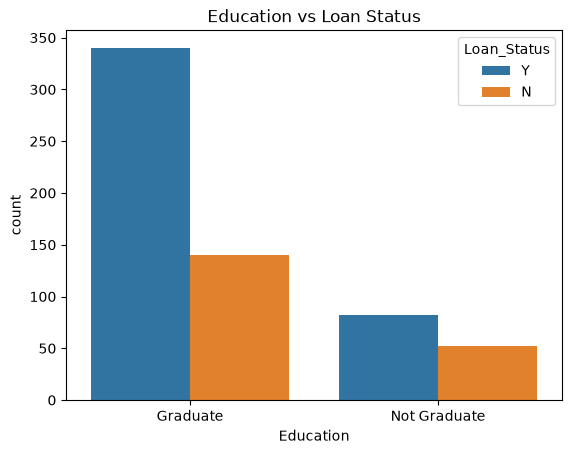

In [9]:
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Education vs Loan Status')
plt.show()

### Married vs Loan Status
**Observation:** Marital status can affect applicant profiles.

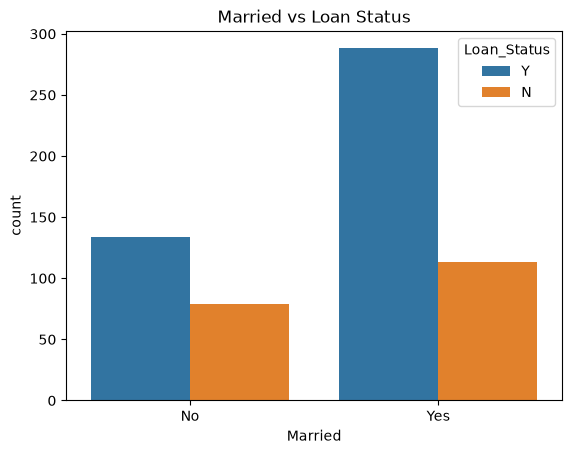

In [10]:
sns.countplot(x='Married', hue='Loan_Status', data=df)
plt.title('Married vs Loan Status')
plt.show()

### Credit History vs Loan Status
**Observation:** Credit history is often one of the strongest predictors.

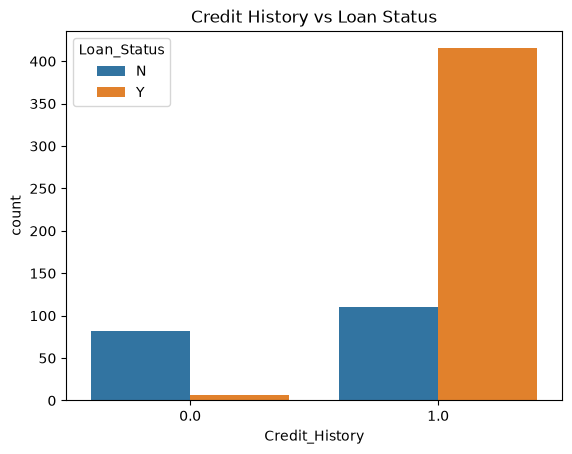

In [11]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Status')
plt.show()

### Applicant Income Distribution
**Observation:** Shows the spread of applicant incomes.

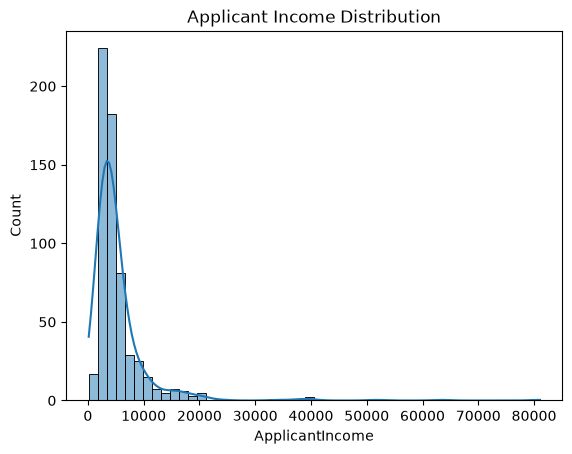

In [12]:
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title('Applicant Income Distribution')
plt.show()

### Coapplicant Income Distribution
**Observation:** Shows coapplicant income variation.

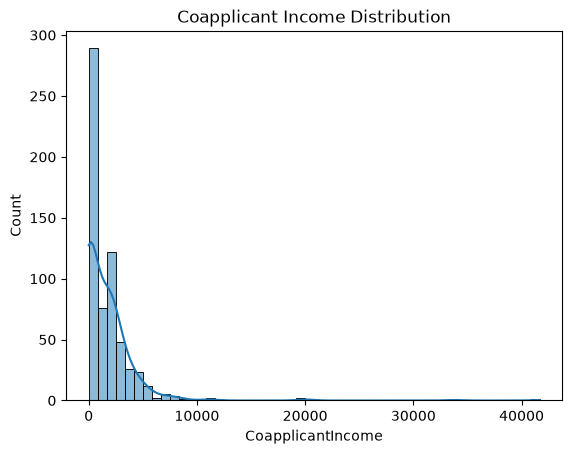

In [13]:
sns.histplot(df['CoapplicantIncome'], kde=True)
plt.title('Coapplicant Income Distribution')
plt.show()

### Loan Amount Distribution
**Observation:** Helps understand loan demand patterns.

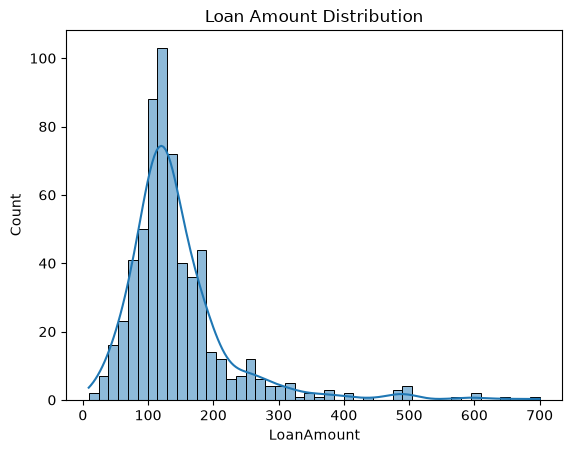

In [14]:
sns.histplot(df['LoanAmount'], kde=True)
plt.title('Loan Amount Distribution')
plt.show()

### Loan Amount Boxplot
**Observation:** Used to identify outliers.

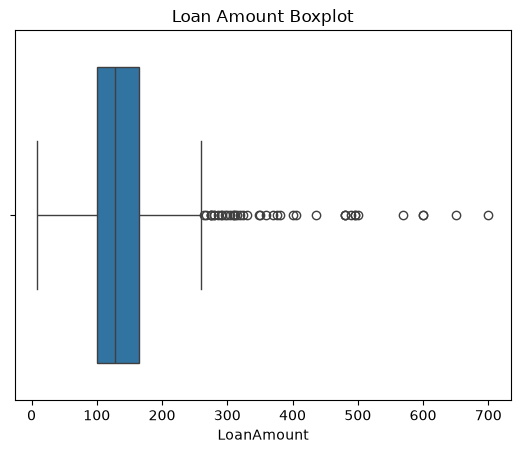

In [15]:
sns.boxplot(x=df['LoanAmount'])
plt.title('Loan Amount Boxplot')
plt.show()

### Income vs Loan Amount
**Observation:** Relationship between income and requested loan amount.

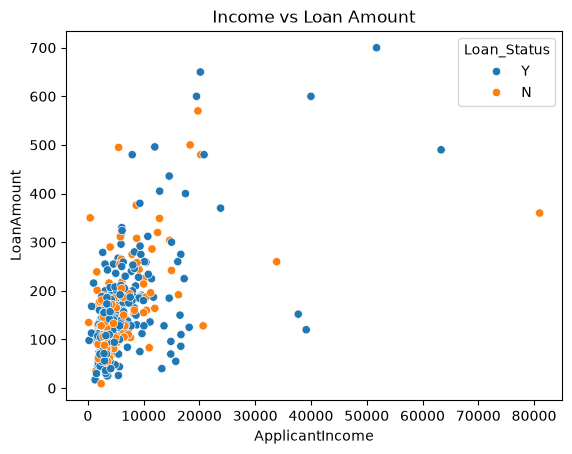

In [16]:
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', data=df)
plt.title('Income vs Loan Amount')
plt.show()

## Feature Encoding & Correlation

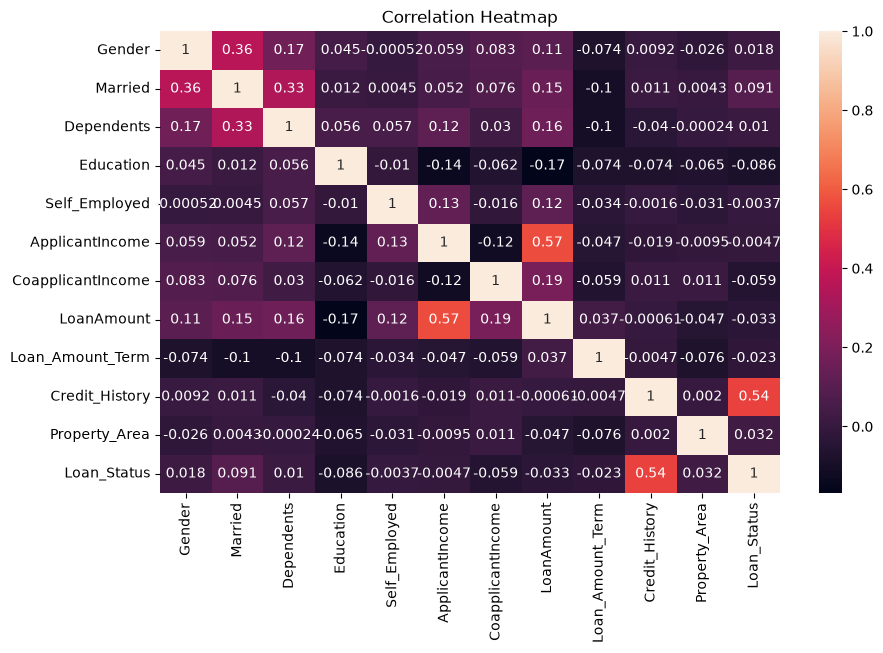

In [17]:

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()


## Model Building

In [18]:

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


### Logistic Regression

In [19]:

lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Accuracy:", lr_acc)
print(classification_report(y_test, lr_pred))


Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



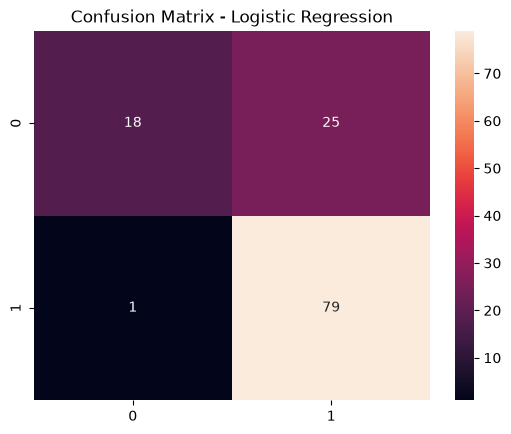

In [20]:

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


### Decision Tree

In [21]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)


Decision Tree Accuracy: 0.6910569105691057


## Model Comparison

In [22]:

results = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree'],
    'Accuracy':[lr_acc, dt_acc]
})
results.sort_values('Accuracy', ascending=False)


,Model,Accuracy
0,Logistic Regression,0.788618
1,Decision Tree,0.691057



# Key Insights

1. Credit History has a major impact on loan approval.
2. Income and Loan Amount influence lending decisions.
3. Proper data cleaning improves model reliability.
4. Logistic Regression provides a strong baseline classifier.

# Conclusion

In this Task, the Loan Prediction dataset was analyzed and preprocessed by handling missing values and encoding categorical features. Exploratory Data Analysis (EDA) was performed to understand the relationships between applicant characteristics and loan approval status. Logistic Regression and Decision Tree models were trained and evaluated using accuracy and confusion matrix. The results show that factors such as credit history, income, and loan amount play an important role in predicting loan approval decisions.
